In [1]:
# Import all necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [2]:
from sklearn.datasets import fetch_california_housing

# Load dataset
housing = fetch_california_housing()

# Convert to DataFrame
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['Price'] = housing.target  # Target column (house price)

print("✅ Dataset loaded!")
print(df.shape)
df.head()

✅ Dataset loaded!
(20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
# Basic info
print("📊 Dataset Info:")
print(df.info())

print("\n📊 Statistical Summary:")
df.describe()

📊 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Price       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None

📊 Statistical Summary:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [4]:
# Check for missing values
print("🔍 Missing Values:")
print(df.isnull().sum())

🔍 Missing Values:
MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
Price         0
dtype: int64


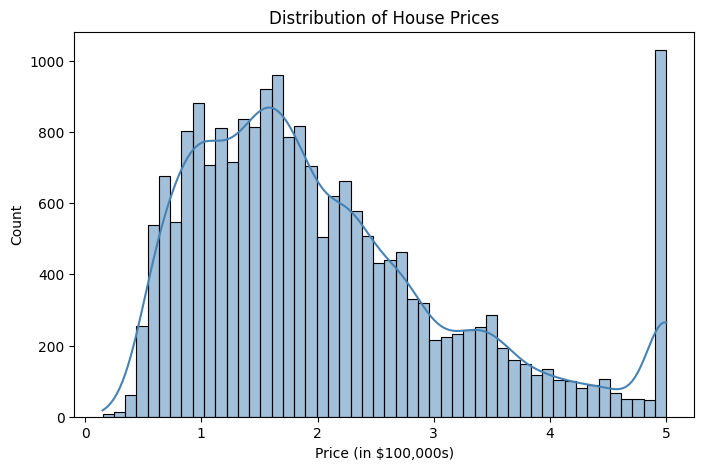

In [5]:
# Visualize distribution of target variable (Price)
plt.figure(figsize=(8,5))
sns.histplot(df['Price'], bins=50, kde=True, color='steelblue')
plt.title('Distribution of House Prices')
plt.xlabel('Price (in $100,000s)')
plt.show()

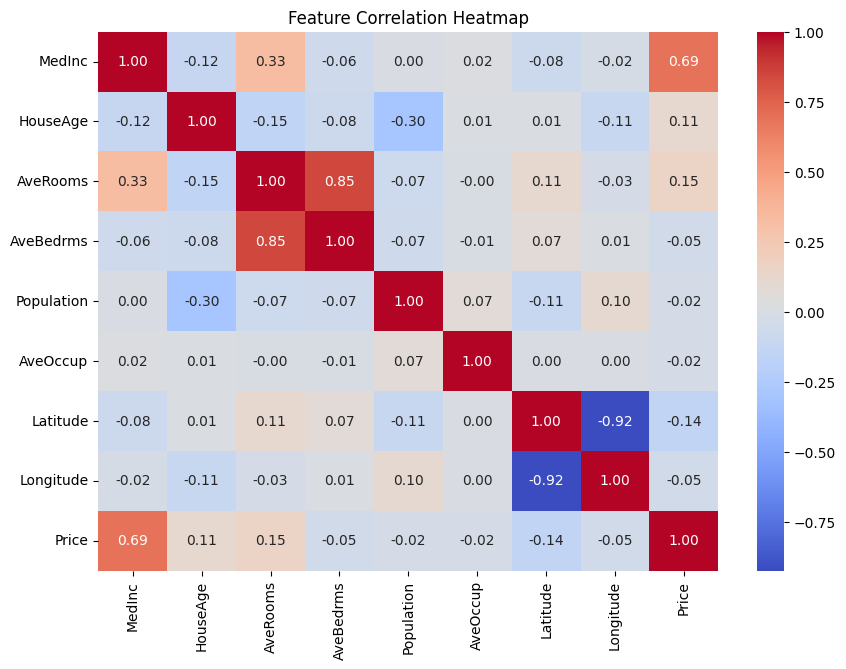

In [6]:
# Correlation Heatmap
plt.figure(figsize=(10,7))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

In [7]:
# Separate features and target
X = df.drop('Price', axis=1)
y = df['Price']

print("✅ Features shape:", X.shape)
print("✅ Target shape:", y.shape)

✅ Features shape: (20640, 8)
✅ Target shape: (20640,)


In [8]:
# Train-Test Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("✅ Train size:", X_train.shape)
print("✅ Test size:", X_test.shape)

✅ Train size: (16512, 8)
✅ Test size: (4128, 8)


In [9]:
# Feature Scaling using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  # ⚠️ Only transform, don't fit on test!

print("✅ Scaling done!")

✅ Scaling done!


In [10]:
# 1️⃣ Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

# 2️⃣ Ridge Regression (L2)
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

# 3️⃣ Lasso Regression (L1)
lasso = Lasso(alpha=0.1)
lasso.fit(X_train_scaled, y_train)

print("✅ All 3 models trained!")

✅ All 3 models trained!


In [11]:
# Function to evaluate model
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    print(f"📌 {name}")
    print(f"   RMSE  : {rmse:.4f}")
    print(f"   R² Score : {r2:.4f}")
    print("-" * 35)
    return y_pred, rmse, r2

# Evaluate all 3
pred_lr,    rmse_lr,    r2_lr    = evaluate_model("Linear Regression", lr, X_test_scaled, y_test)
pred_ridge, rmse_ridge, r2_ridge = evaluate_model("Ridge Regression",  ridge, X_test_scaled, y_test)
pred_lasso, rmse_lasso, r2_lasso = evaluate_model("Lasso Regression",  lasso, X_test_scaled, y_test)

📌 Linear Regression
   RMSE  : 0.7456
   R² Score : 0.5758
-----------------------------------
📌 Ridge Regression
   RMSE  : 0.7456
   R² Score : 0.5758
-----------------------------------
📌 Lasso Regression
   RMSE  : 0.8244
   R² Score : 0.4814
-----------------------------------


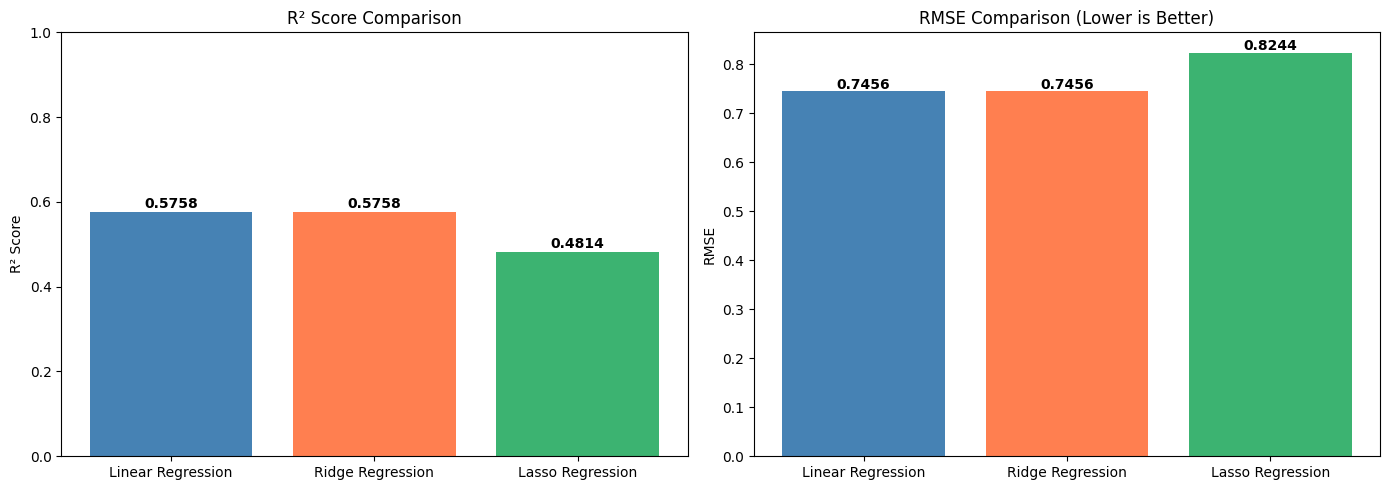

In [12]:
# Bar chart comparing R² scores
models = ['Linear Regression', 'Ridge Regression', 'Lasso Regression']
r2_scores = [r2_lr, r2_ridge, r2_lasso]
rmse_scores = [rmse_lr, rmse_ridge, rmse_lasso]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# R² Score
axes[0].bar(models, r2_scores, color=['steelblue', 'coral', 'mediumseagreen'])
axes[0].set_title('R² Score Comparison')
axes[0].set_ylabel('R² Score')
axes[0].set_ylim(0, 1)
for i, v in enumerate(r2_scores):
    axes[0].text(i, v + 0.01, f"{v:.4f}", ha='center', fontweight='bold')

# RMSE
axes[1].bar(models, rmse_scores, color=['steelblue', 'coral', 'mediumseagreen'])
axes[1].set_title('RMSE Comparison (Lower is Better)')
axes[1].set_ylabel('RMSE')
for i, v in enumerate(rmse_scores):
    axes[1].text(i, v + 0.005, f"{v:.4f}", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

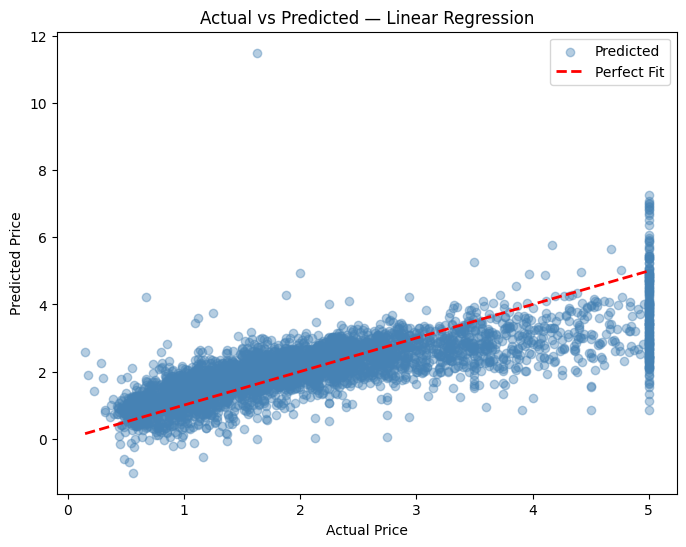

In [13]:
# Actual vs Predicted Plot for best model
plt.figure(figsize=(8,6))
plt.scatter(y_test, pred_lr, alpha=0.4, color='steelblue', label='Predicted')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Fit')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted — Linear Regression')
plt.legend()
plt.show()

In [15]:
print("=" * 45)
print("      🏠 HOUSE PRICE PREDICTION SUMMARY")
print("=" * 45)
print(f"  Linear Regression → R²: {r2_lr:.4f} | RMSE: {rmse_lr:.4f}")
print(f"  Ridge Regression  → R²: {r2_ridge:.4f} | RMSE: {rmse_ridge:.4f}")
print(f"  Lasso Regression  → R²: {r2_lasso:.4f} | RMSE: {rmse_lasso:.4f}")
print("=" * 45)

best = models[r2_scores.index(max(r2_scores))]
print(f"\n🏆 Best Model: {best}")


      🏠 HOUSE PRICE PREDICTION SUMMARY
  Linear Regression → R²: 0.5758 | RMSE: 0.7456
  Ridge Regression  → R²: 0.5758 | RMSE: 0.7456
  Lasso Regression  → R²: 0.4814 | RMSE: 0.8244

🏆 Best Model: Ridge Regression
